Price,Price
Date,
1980-01-02,105.760002
1980-01-03,105.220001
1980-01-04,106.519997
1980-01-07,106.809998
1980-01-08,108.949997


Number of daily returns: 11344
Sample: 1980-01-03 to 2024-12-31
Best log-likelihood: -15052.7215
Converged: True
Iterations: 191


,seed,log_likelihood,converged,iterations
14,14,"-15,052.721527",True,191
7,7,"-15,052.721533",True,73
2,2,"-15,052.721533",True,128
8,8,"-15,052.721539",True,219
6,6,"-15,052.721541",True,103


Estimated Gaussian parameters:


,Regime,Mean (%),Std. Dev. (%),Variance,Annualized Volatility (%),Initial Probability
0,Low Volatility,0.089191,0.592757,0.351361,9.409732,0.000000
1,Medium Volatility,0.006967,1.140450,1.300626,18.104078,1.000000
2,High Volatility,-0.213492,2.955608,8.735620,46.918826,0.000000


...

Expected regime duration:


,Regime,Self-transition Probability,Expected Duration (days)
0,Low Volatility,0.978870,47.325728
1,Medium Volatility,0.969233,32.502067
2,High Volatility,0.955508,22.475747


Viterbi regime frequency:


,Frequency
Regime,
Low Volatility,0.520275
Medium Volatility,0.425864
High Volatility,0.053861


,Regime,Self-transition Probability,Expected Duration (days),Viterbi Frequency
0,Low Volatility,0.978870,47.325728,0.520275
1,Medium Volatility,0.969233,32.502067,0.425864
2,High Volatility,0.955508,22.475747,0.053861


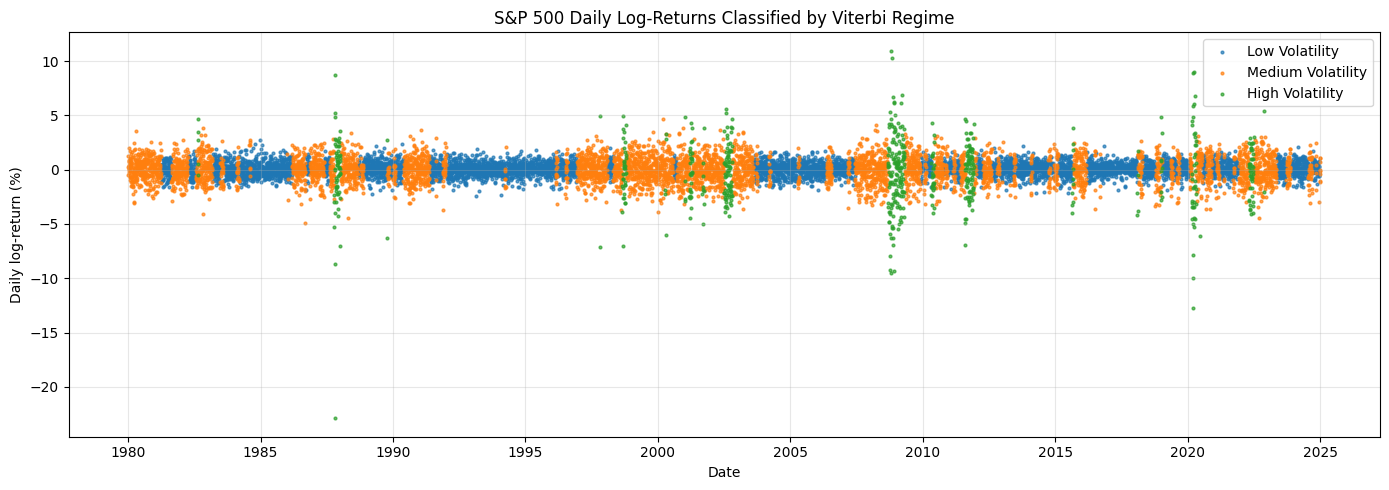

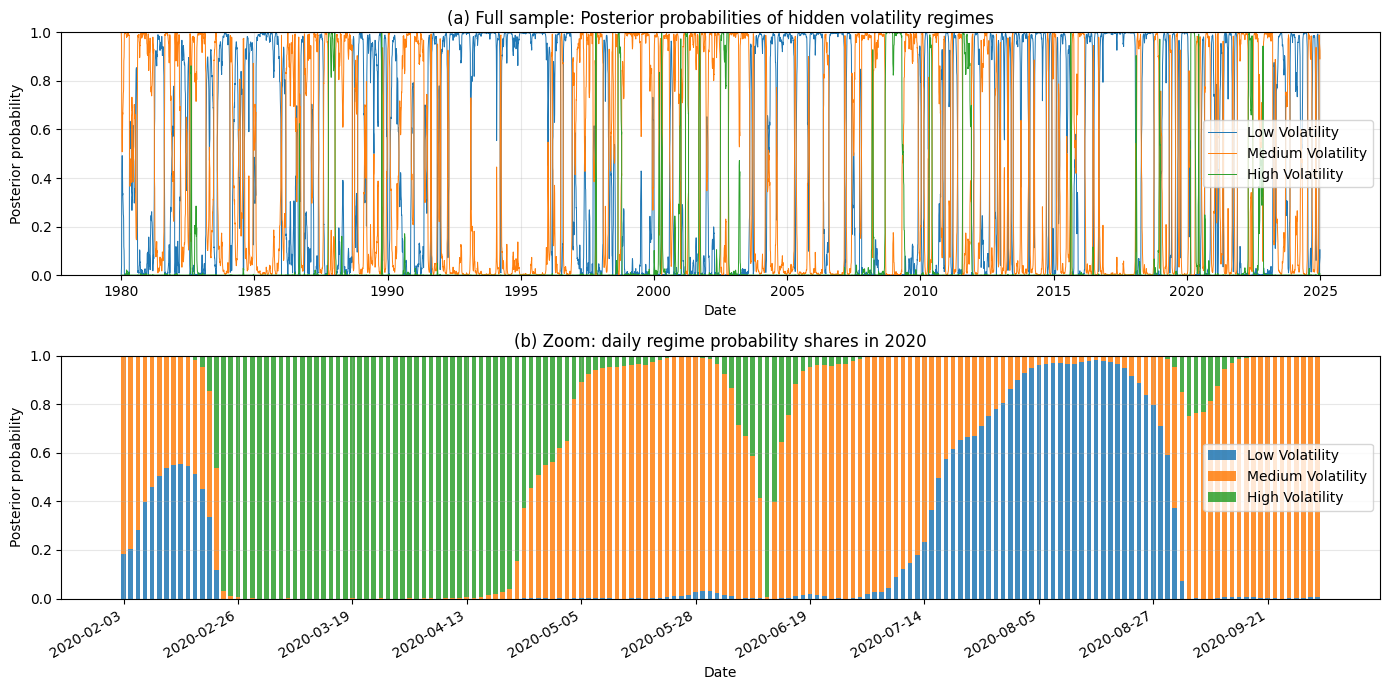

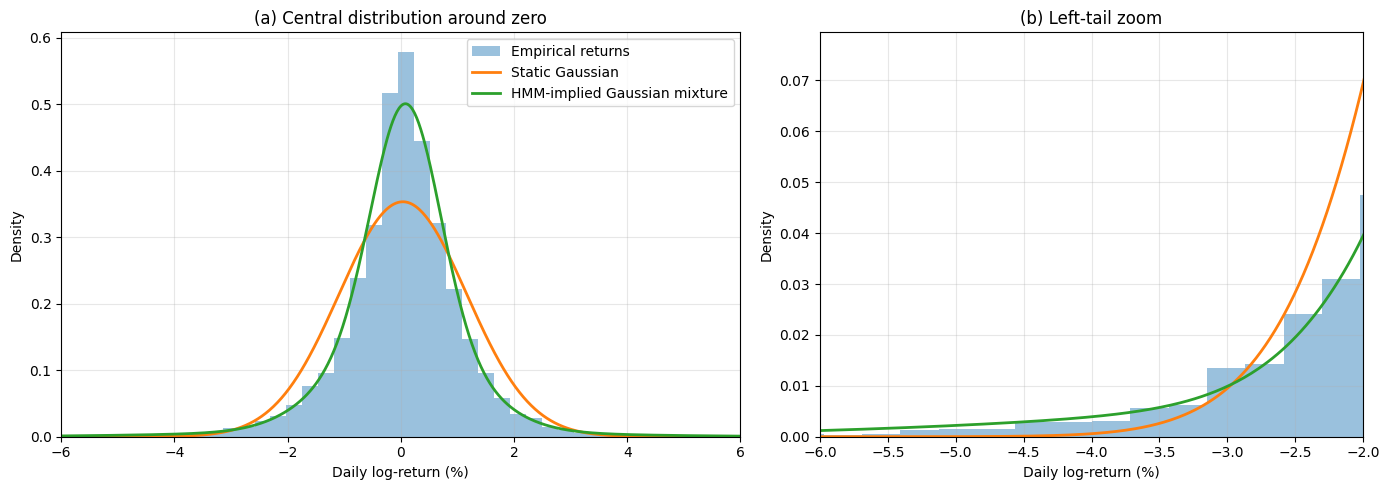

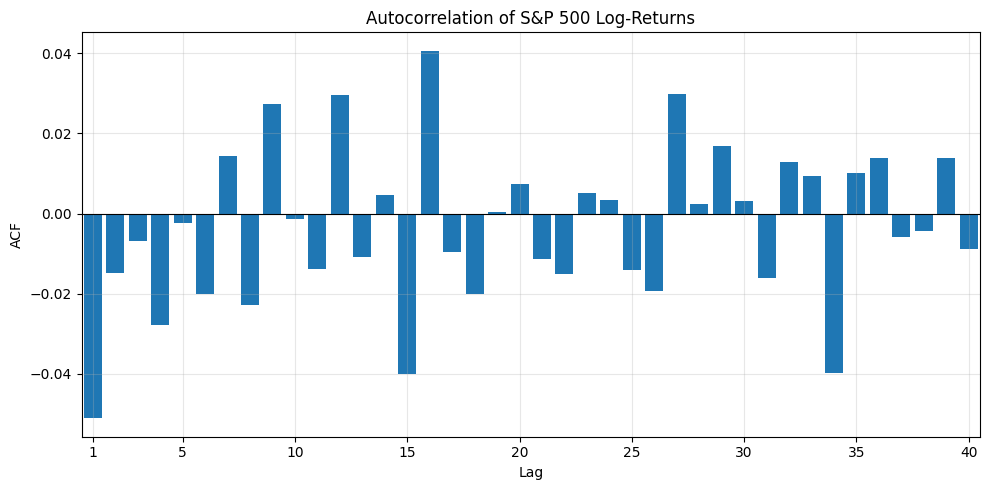

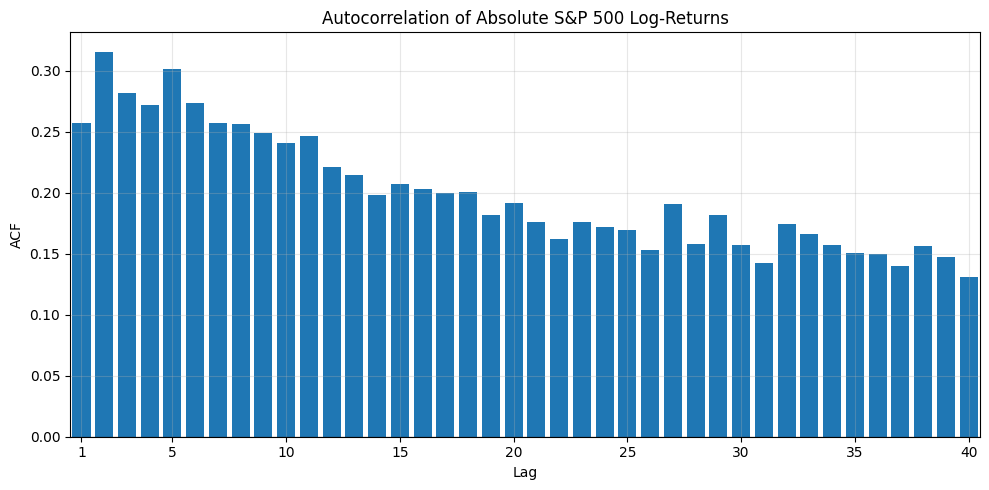

Final numerical outputs and thesis figures saved in: /Users/sofia/Desktop/BSc Management Engineering/Tesi Finale - 3 CFU/Grafici


In [2]:
# Hidden Markov Model on S&P 500 Returns

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

from hmmlearn.hmm import GaussianHMM
from pathlib import Path
from IPython.display import display


# Constant parameters setup
N_STATES = 3
TRADING_DAYS = 252

OUTPUT_DIR = Path.home() / "Desktop" / "BSc Management Engineering" / "Tesi Finale - 3 CFU" / "Grafici"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

REGIME_COLORS = {
    0: "#1f77b4",
    1: "#ff7f0e",
    2: "#2ca02c"
}

pd.set_option("display.float_format", lambda x: f"{x:,.6f}")


# S&P 500 data retrieval and preprocessing pipeline
data_raw = yf.download(
    "^GSPC",
    start="1980-01-01",
    end="2025-01-01",
    progress=False
)

if isinstance(data_raw.columns, pd.MultiIndex):
    data_raw.columns = data_raw.columns.get_level_values(0)

if data_raw.empty:
    raise ValueError(
        "No data downloaded. Check the ticker, dates or internet connection"
    )

if "Close" not in data_raw.columns:
    raise ValueError(
        f"Column 'Close' not found. Available columns: "
        f"{data_raw.columns.tolist()}"
    )

# Isolate closing prices, remove missing values and order chronologically
data = (
    data_raw[["Close"]]
    .rename(columns={"Close": "Price"})
    .dropna()
    .sort_index()
)

display(data.head())


# Computing log-returns from current and previous closing prices
data["LogReturn"] = np.log(
    data["Price"] / data["Price"].shift(1)
)

# Scaling returns to percentage terms
data["LogReturnPct"] = 100 * data["LogReturn"]

# Removal of undefined values generated by the lagged division
data = data.replace(
    [np.inf, -np.inf],
    np.nan
).dropna()

# Reshaping the observable sequence into a 2D input matrix
returns = data["LogReturnPct"].values.reshape(-1, 1)

print("Number of daily returns:", len(returns))
print(
    "Sample:",
    data.index.min().date(),
    "to",
    data.index.max().date()
)


def fit_gaussian_hmm_with_restarts(
    X,
    n_states,
    random_states=range(10),
    covariance_type="diag",
    n_iter=1000,
    tol=1e-4
):
    # Storage for the best fitted model
    best_model = None
    best_log_likelihood = -np.inf
    restart_summary = []

    for seed in random_states:
        # Same HMM specification, different initialization
        model = GaussianHMM(
            n_components=n_states,
            covariance_type=covariance_type,
            n_iter=n_iter,
            tol=tol,
            random_state=seed
        )

        # Estimate alpha, P, means and variances through Baum-Welch
        model.fit(X)

        log_likelihood = model.score(X)

        # Save convergence information for this restart
        restart_summary.append([
            seed,
            log_likelihood,
            model.monitor_.converged,
            model.monitor_.iter
        ])

        # Keep the model with the highest log-likelihood
        if log_likelihood > best_log_likelihood:
            best_log_likelihood = log_likelihood
            best_model = model

    restart_summary = pd.DataFrame(
        restart_summary,
        columns=[
            "seed",
            "log_likelihood",
            "converged",
            "iterations"
        ]
    )

    return best_model, restart_summary


# Final estimation of the three-state Gaussian HMM
model, restart_results = fit_gaussian_hmm_with_restarts(
    returns,
    n_states=N_STATES,
    random_states=range(20),
    covariance_type="diag",
    n_iter=1000,
    tol=1e-4
)

# Extract convergence metrics for the optimal candidate
log_likelihood = model.score(returns)
converged = model.monitor_.converged
iterations = model.monitor_.iter

# Rank all initialization attempts to assess stability
restart_results = restart_results.sort_values(
    "log_likelihood",
    ascending=False
)

print("Best log-likelihood:", round(log_likelihood, 4))
print("Converged:", converged)
print("Iterations:", iterations)

display(restart_results.head())


# Extract raw estimated HMM parameters
startprob_raw = model.startprob_
transmat_raw = model.transmat_
means_raw = model.means_.flatten()

# Extract state-specific variances and standard deviations
covars_raw = np.array(
    model.covars_
).reshape(N_STATES, -1)

variances_raw = covars_raw[:, 0]
std_raw = np.sqrt(variances_raw)


# Global decoding (Viterbi): optimal deterministic hidden-state path
hidden_states_raw = model.predict(returns)

# Local decoding (Forward-Backward): smoothed posterior probabilities
posterior_probs_raw = model.predict_proba(returns)

# Append the deterministic Viterbi classification to the dataset
data_model = data.copy()
data_model["RawState"] = hidden_states_raw


# Order hidden states by estimated standard deviation
state_order = np.argsort(std_raw)

ordered_names = {
    0: "Low Volatility",
    1: "Medium Volatility",
    2: "High Volatility"
}

# Map raw arbitrary indices to economically ordered indices
raw_to_ordered = {
    raw_state: ordered_state
    for ordered_state, raw_state in enumerate(state_order)
}

# Add ordered state labels to the empirical dataset
data_model["State"] = data_model["RawState"].map(
    raw_to_ordered
)

data_model["Regime"] = data_model["State"].map(
    ordered_names
)


# Reorder initial probabilities
startprob_ordered = startprob_raw[state_order]

# Permute the K x K transition matrix
transmat_ordered = transmat_raw[
    np.ix_(state_order, state_order)
]

# Reorder 1D Gaussian emission parameters
means_ordered = means_raw[state_order]
variances_ordered = variances_raw[state_order]
std_ordered = std_raw[state_order]

# Reorder the state columns of the T x K posterior probability matrix
posterior_probs_ordered = posterior_probs_raw[
    :,
    state_order
]


# State-specific Gaussian emission parameters
parameter_table = pd.DataFrame({
    "Regime": [
        ordered_names[i]
        for i in range(N_STATES)
    ],
    "Mean (%)": means_ordered,
    "Std. Dev. (%)": std_ordered,
    "Variance": variances_ordered,
    "Annualized Volatility (%)": (
        std_ordered * np.sqrt(TRADING_DAYS)
    ),
    "Initial Probability": startprob_ordered
})

# Transition matrix ordered by volatility regime
transition_table = pd.DataFrame(
    transmat_ordered,
    index=[
        ordered_names[i]
        for i in range(N_STATES)
    ],
    columns=[
        ordered_names[i]
        for i in range(N_STATES)
    ]
)

# Expected duration implied by the self-transition probabilities
expected_duration = pd.DataFrame({
    "Regime": [
        ordered_names[i]
        for i in range(N_STATES)
    ],
    "Self-transition Probability": np.diag(transmat_ordered),
    "Expected Duration (days)": (
        1 / (1 - np.diag(transmat_ordered))
    )
})

print("Estimated Gaussian parameters:")
display(parameter_table)

print("Estimated transition matrix:")
display(transition_table)

print("Expected regime duration:")
display(expected_duration)


# Empirical frequency of each Viterbi regime
regime_frequency = (
    data_model["Regime"]
    .value_counts(normalize=True)
    .reindex([
        ordered_names[i]
        for i in range(N_STATES)
    ])
    .rename("Frequency")
    .to_frame()
)

print("Viterbi regime frequency:")
display(regime_frequency)


# Combined summary corresponding to the persistence analysis in Chapter 6
persistence_table = expected_duration.copy()

persistence_table["Viterbi Frequency"] = (
    regime_frequency["Frequency"].values
)

display(persistence_table)


# Figure 6.1
# Viterbi classification of S&P 500 daily log-returns by volatility regime

plt.figure(figsize=(14, 5))

for state in range(N_STATES):
    subset = data_model[
        data_model["State"] == state
    ]

    plt.scatter(
        subset.index,
        subset["LogReturnPct"],
        s=4,
        label=ordered_names[state],
        alpha=0.7,
        color=REGIME_COLORS[state]
    )

plt.title(
    "S&P 500 Daily Log-Returns Classified by Viterbi Regime"
)

plt.xlabel("Date")
plt.ylabel("Daily log-return (%)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

# Export figure for the thesis
plt.savefig(
    OUTPUT_DIR / "fig_6_1_viterbi_regimes_returns.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.show()


# Figure 6.2
# Smoothed posterior probabilities obtained through Forward-Backward
# Panel (a) reports the full sample
# Panel (b) focuses on the 2020 market-stress period

posterior_df = pd.DataFrame(
    posterior_probs_ordered,
    index=data_model.index,
    columns=[
        ordered_names[i]
        for i in range(N_STATES)
    ]
)

zoom_start = "2020-02-01"
zoom_end = "2020-09-30"

posterior_zoom = posterior_df.loc[
    zoom_start:zoom_end
]

fig, axes = plt.subplots(
    2,
    1,
    figsize=(14, 7),
    sharey=True
)

# Panel (a): full-sample posterior probabilities
for state, regime in enumerate(posterior_df.columns):
    axes[0].plot(
        posterior_df.index,
        posterior_df[regime],
        linewidth=0.7,
        label=regime,
        color=REGIME_COLORS[state]
    )

axes[0].set_title(
    "(a) Full sample: Posterior probabilities of hidden volatility regimes"
)

axes[0].set_xlabel("Date")
axes[0].set_ylabel("Posterior probability")
axes[0].legend(loc="center right")
axes[0].grid(alpha=0.3)

# Panel (b): stacked daily regime probabilities in 2020
x_positions = np.arange(len(posterior_zoom))
bottom = np.zeros(len(posterior_zoom))

for state, regime in enumerate(posterior_zoom.columns):
    axes[1].bar(
        x_positions,
        posterior_zoom[regime].values,
        bottom=bottom,
        width=0.65,
        label=regime,
        color=REGIME_COLORS[state],
        alpha=0.85
    )

    bottom += posterior_zoom[regime].values

tick_step = max(1, len(posterior_zoom) // 10)
tick_positions = x_positions[::tick_step]
tick_labels = [
    date.strftime("%Y-%m-%d")
    for date in posterior_zoom.index[::tick_step]
]

axes[1].set_xticks(tick_positions)
axes[1].set_xticklabels(
    tick_labels,
    rotation=30,
    ha="right"
)

axes[1].set_ylim(0, 1)

axes[1].set_title(
    "(b) Zoom: daily regime probability shares in 2020"
)

axes[1].set_xlabel("Date")
axes[1].set_ylabel("Posterior probability")
axes[1].legend(loc="center right")
axes[1].grid(alpha=0.3)

plt.tight_layout()

# Export figure for the thesis
plt.savefig(
    OUTPUT_DIR / "fig_6_2_posterior_probabilities.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.show()


def normal_pdf(x, mean, std):
    return (
        1 / (std * np.sqrt(2 * np.pi))
    ) * np.exp(
        -0.5 * ((x - mean) / std) ** 2
    )


# Figure 6.3
# Empirical distribution compared with a static Gaussian density and the HMM-implied mixture
# Panel (a) shows the central distribution around zero
# Panel (b) zooms into the left tail

returns_series = data_model["LogReturnPct"]

x_grid = np.linspace(
    returns_series.min() - 0.5,
    returns_series.max() + 0.5,
    2000
)

static_mean = returns_series.mean()
static_std = returns_series.std()

static_density = normal_pdf(
    x_grid,
    static_mean,
    static_std
)

mixture_weights = posterior_probs_ordered.mean(
    axis=0
)

hmm_density = np.zeros_like(x_grid)

for i in range(N_STATES):
    hmm_density += (
        mixture_weights[i]
        * normal_pdf(
            x_grid,
            means_ordered[i],
            std_ordered[i]
        )
    )

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5),
    gridspec_kw={
        "width_ratios": [1.25, 1]
    }
)

# Panel (a): empirical distribution around the center
axes[0].hist(
    returns_series,
    bins=120,
    density=True,
    alpha=0.45,
    label="Empirical returns",
    color="#1f77b4"
)

axes[0].plot(
    x_grid,
    static_density,
    linewidth=2,
    label="Static Gaussian",
    color="#ff7f0e"
)

axes[0].plot(
    x_grid,
    hmm_density,
    linewidth=2,
    label="HMM-implied Gaussian mixture",
    color="#2ca02c"
)

axes[0].set_xlim(-6, 6)

axes[0].set_title(
    "(a) Central distribution around zero"
)

axes[0].set_xlabel("Daily log-return (%)")
axes[0].set_ylabel("Density")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Panel (b): left-tail zoom
x_zoom_min = -6
x_zoom_max = -2

zoom_mask = (
    (x_grid >= x_zoom_min)
    & (x_grid <= x_zoom_max)
)

hist_vals, hist_bins = np.histogram(
    returns_series,
    bins=120,
    density=True
)

bin_centers = 0.5 * (
    hist_bins[:-1]
    + hist_bins[1:]
)

hist_zoom_mask = (
    (bin_centers >= x_zoom_min)
    & (bin_centers <= x_zoom_max)
)

y_zoom_max = max(
    hist_vals[hist_zoom_mask].max(),
    static_density[zoom_mask].max(),
    hmm_density[zoom_mask].max()
) * 1.15

axes[1].hist(
    returns_series,
    bins=120,
    density=True,
    alpha=0.45,
    label="Empirical returns",
    color="#1f77b4"
)

axes[1].plot(
    x_grid,
    static_density,
    linewidth=2,
    label="Static Gaussian",
    color="#ff7f0e"
)

axes[1].plot(
    x_grid,
    hmm_density,
    linewidth=2,
    label="HMM-implied Gaussian mixture",
    color="#2ca02c"
)

axes[1].set_xlim(
    x_zoom_min,
    x_zoom_max
)

axes[1].set_ylim(
    0,
    y_zoom_max
)

axes[1].set_title(
    "(b) Left-tail zoom"
)

axes[1].set_xlabel("Daily log-return (%)")
axes[1].set_ylabel("Density")
axes[1].grid(alpha=0.3)

plt.tight_layout()

# Export figure for the thesis
plt.savefig(
    OUTPUT_DIR / "fig_6_3_static_gaussian_vs_hmm_mixture.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.show()


def autocorrelation(series, max_lag=40):
    s = pd.Series(series).dropna()

    return np.array([
        s.autocorr(lag)
        for lag in range(max_lag + 1)
    ])


MAX_LAG = 40

acf_returns = autocorrelation(
    data_model["LogReturnPct"],
    max_lag=MAX_LAG
)

acf_abs_returns = autocorrelation(
    np.abs(data_model["LogReturnPct"]),
    max_lag=MAX_LAG
)

# The displayed lags start from 1 because lag zero is equal to one by construction
acf_lags = np.arange(
    1,
    MAX_LAG + 1
)


# Figure 6.4
# Autocorrelation of daily log-returns excluding lag zero

plt.figure(figsize=(10, 5))

plt.bar(
    acf_lags,
    acf_returns[1:],
    color="#1f77b4"
)

plt.axhline(
    0,
    linewidth=0.8,
    color="black"
)

plt.xlim(0.5, MAX_LAG + 0.5)
plt.xticks([1, 5, 10, 15, 20, 25, 30, 35, 40])

plt.title(
    "Autocorrelation of S&P 500 Log-Returns"
)

plt.xlabel("Lag")
plt.ylabel("ACF")
plt.grid(alpha=0.3)
plt.tight_layout()

# Export figure for the thesis
plt.savefig(
    OUTPUT_DIR / "fig_6_4_acf_returns.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.show()


# Figure 6.5
# Autocorrelation of absolute daily log-returns excluding lag zero

plt.figure(figsize=(10, 5))

plt.bar(
    acf_lags,
    acf_abs_returns[1:],
    color="#1f77b4"
)

plt.axhline(
    0,
    linewidth=0.8,
    color="black"
)

plt.xlim(0.5, MAX_LAG + 0.5)
plt.xticks([1, 5, 10, 15, 20, 25, 30, 35, 40])

plt.title(
    "Autocorrelation of Absolute S&P 500 Log-Returns"
)

plt.xlabel("Lag")
plt.ylabel("ACF")
plt.grid(alpha=0.3)
plt.tight_layout()

# Export figure for the thesis
plt.savefig(
    OUTPUT_DIR / "fig_6_5_acf_absolute_returns.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.show()


# Save the numerical outputs used in the empirical analysis

parameter_table.to_csv(
    OUTPUT_DIR / "hmm_parameter_table.csv",
    index=False
)

transition_table.to_csv(
    OUTPUT_DIR / "hmm_transition_matrix.csv"
)

expected_duration.to_csv(
    OUTPUT_DIR / "hmm_expected_duration.csv",
    index=False
)

regime_frequency.to_csv(
    OUTPUT_DIR / "hmm_regime_frequency.csv"
)

persistence_table.to_csv(
    OUTPUT_DIR / "hmm_persistence_summary.csv",
    index=False
)

print(
    "Final numerical outputs and thesis figures saved in:",
    OUTPUT_DIR.resolve()
)

In [2]:
%pip install yfinance hmmlearn
%pip install hmmlearn

  Using cached hmmlearn-0.3.3-cp314-cp314-macosx_10_15_universal2.whl
  Using cached scikit_learn-1.9.0-cp314-cp314-macosx_12_0_arm64.whl.metadata (11 kB)
  Using cached joblib-1.6.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached narwhals-2.25.0-py3-none-any.whl.metadata (15 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached cloudpickle-3.1.2-py3-none-any.whl.metadata (7.1 kB)
Using cached scikit_learn-1.9.0-cp314-cp314-macosx_12_0_arm64.whl (8.2 MB)
Using cached joblib-1.6.0-py3-none-any.whl (306 kB)
Using cached cloudpickle-3.1.2-py3-none-any.whl (22 kB)
Using cached narwhals-2.25.0-py3-none-any.whl (467 kB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [hmmlearn]4/6 [scikit-learn]

[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: pip3.14 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of